# 📊 Challenge Telecom X - Parte 2: Predicción de Churn
**Analista Junior de Machine Learning:** Constanza Mena

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Esta es la única forma correcta de importar Seaborn

# Configuración para que los gráficos se vean mejor
%matplotlib inline
sns.set(style="whitegrid")

# 1. Carga del dataset tratado en la Parte 1
# Asegúrate de haber arrastrado el archivo a la carpeta lateral de Colab
df = pd.read_csv('datos_tratados.csv')

# 2. Verificación rápida
print(f"✅ Dataset cargado con {df.shape[0]} registros.")
df.head()

✅ Dataset cargado con 7267 registros.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# 🛠️ 1. Preparación de los Datos para Machine Learning
En esta etapa, transformaremos los datos brutos en un formato que los algoritmos puedan procesar eficientemente.

**1.1 Eliminación de Columnas Irrelevantes**

In [5]:
# Como ya cargué el df arriba, vamos a limpiar lo que no sirve para predecir
# El ID del cliente no ayuda a predecir, así que lo eliminamos si existe
columnas_a_eliminar = ['customerID', 'id'] # Ajusta según los nombres exactos en el df
df_modelo = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])

print(f"Columnas restantes: {df_modelo.columns.tolist()}")

Columnas restantes: ['Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


**1.2 Encoding (Codificación de Categorías)**

### Encoding
Transformamos variables de texto (Si/No, Tipo de internet) a números usando `get_dummies` para que el modelo pueda realizar cálculos matemáticos.

In [8]:
# Aplicamos One-Hot Encoding a las variables categóricas
df_modelo = pd.get_dummies(df_modelo)

# Verificamos cómo quedaron las nuevas columnas (ahora todo debe ser número)
df_modelo.head()

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,customer.gender_Female,customer.gender_Male,customer.Partner_No,customer.Partner_Yes,customer.Dependents_No,...,internet.StreamingMovies_Yes,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_No,account.PaperlessBilling_Yes,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0.0,0,9,65.6,593.30,True,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True
1,0.0,0,9,59.9,542.40,False,True,True,False,True,...,True,True,False,False,True,False,False,False,False,True
2,1.0,0,4,73.9,280.85,False,True,True,False,True,...,False,True,False,False,False,True,False,False,True,False
3,1.0,1,13,98.0,1237.85,False,True,False,True,True,...,True,True,False,False,False,True,False,False,True,False
4,1.0,1,3,83.9,267.40,True,False,False,True,True,...,False,True,False,False,False,True,False,False,False,True


In [9]:
# Verifica que ejecutaste esto antes
df_modelo = pd.get_dummies(df_modelo)

**1.2.1 Limpieza de valores nulos (Post-Encoding)**

In [16]:
# --- 1.2.1 Limpieza de valores nulos (Post-Encoding) ---

# Eliminamos cualquier fila que tenga valores nulos que hayan surgido o quedado
df_modelo = df_modelo.dropna()

# Reiniciamos los índices para que la tabla quede ordenada
df_modelo = df_modelo.reset_index(drop=True)

print(f"✅ Limpieza completada. Dataset final para el modelo: {df_modelo.shape[0]} registros.")

✅ Limpieza completada. Dataset final para el modelo: 7032 registros.


**1.3 Verificación de la Proporción de Churn**

In [17]:
# Calculamos la proporción para ver si hay desbalanceo
proporcion = df_modelo['Churn'].value_counts(normalize=True) * 100
print("Proporción de Clientes:")
print(f"Se quedan (0): {proporcion[0]:.2f}%")
print(f"Se van (1): {proporcion[1]:.2f}%")

Proporción de Clientes:
Se quedan (0): 73.42%
Se van (1): 26.58%


# 🎯 2. Correlación y Selección de Variables
Identificamos qué variables tienen mayor impacto matemático en la decisión del cliente de cancelar el servicio.

**2.1 Análisis de Correlación**

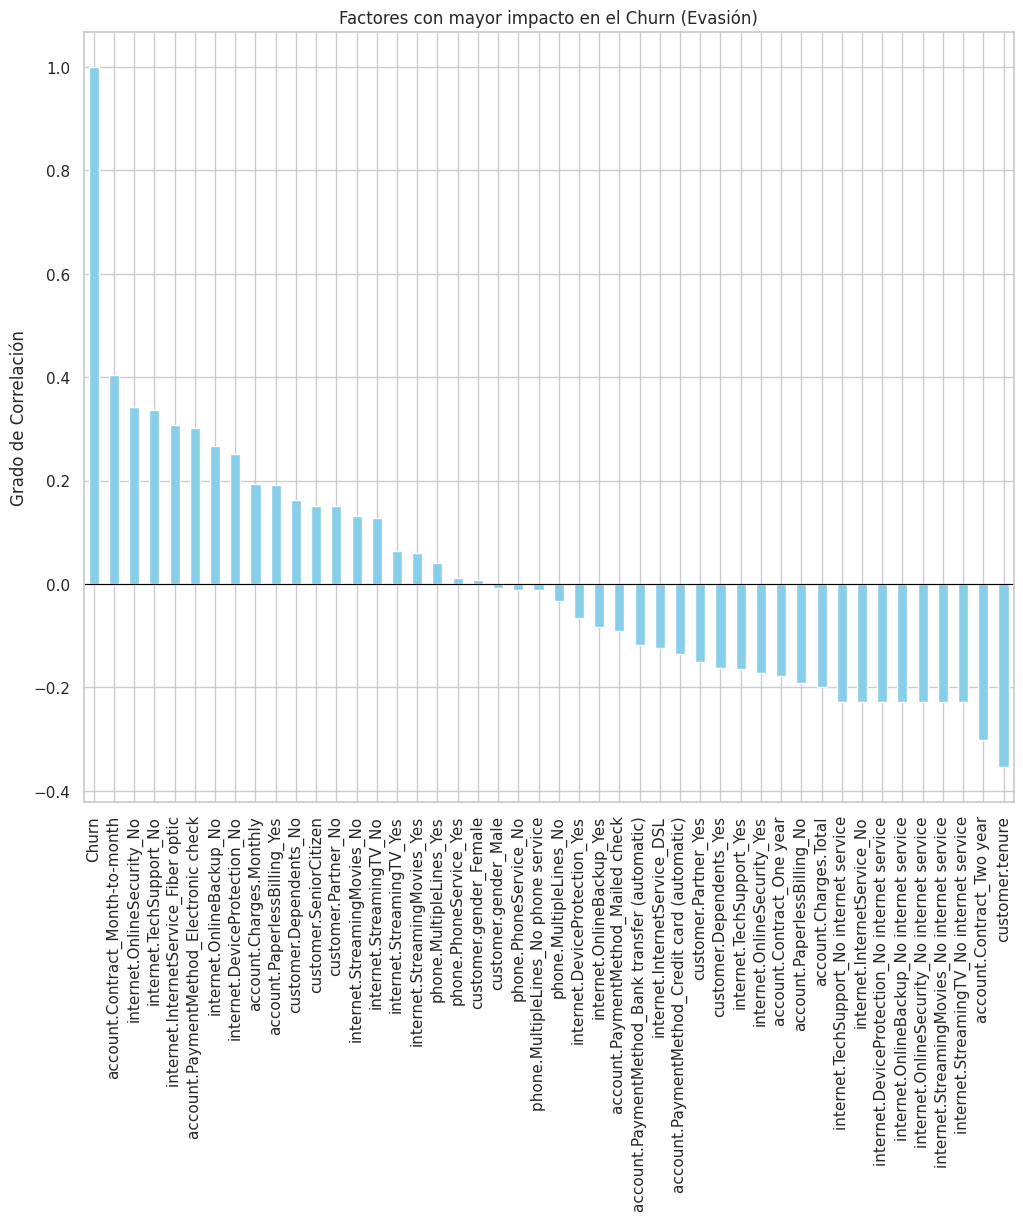

In [18]:
# 2.1 Análisis de Correlación (Versión compatible)
plt.figure(figsize=(12, 10))

# Usamos numeric_only=True para que tome los valores True/False como 1/0
correlacion = df_modelo.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

# Graficamos
correlacion.plot(kind='bar', color='skyblue')
plt.title("Factores con mayor impacto en el Churn (Evasión)")
plt.ylabel("Grado de Correlación")
plt.axhline(0, color='black', linewidth=0.8) # Línea base en 0
plt.show()

# 🤖 3. Modelado Predictivo
Dividiremos los datos y entrenaremos dos modelos: uno sensible a la escala (Regresión Logística) y uno basado en árboles (Random Forest).

In [19]:
from sklearn.model_selection import train_test_split

# Definimos X (características) y y (objetivo)
X = df_modelo.drop('Churn', axis=1)
y = df_modelo['Churn']

# Dividimos 70% entrenamiento y 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 4922
Muestras de prueba: 2110


**3.2 Normalización (Para Regresión Logística)**

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🤖 4. Creación y Evaluación de Modelos
Entrenaremos dos modelos:
1. **Regresión Logística**: Un modelo lineal que requiere datos normalizados.
2. **Random Forest**: Un modelo de ensamble basado en árboles de decisión, muy robusto y que no requiere normalización.

**4.1 Entrenamiento de Regresión Logística**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Creamos y entrenamos el modelo con los datos ESCALADOS (paso 3.2)
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train_scaled, y_train)

# Realizamos predicciones
y_pred_log = modelo_logistico.predict(X_test_scaled)

# Evaluación inicial
print("--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_log):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_log))

--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---
Exactitud (Accuracy): 0.8038

Informe de Clasificación:
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1554
         1.0       0.64      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110



**4.2 Entrenamiento de Random Forest**

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Creamos y entrenamos el modelo con los datos ORIGINALES (los árboles no necesitan escala)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Realizamos predicciones
y_pred_rf = modelo_rf.predict(X_test)

# Evaluación inicial
print("--- MÉTRICAS: RANDOM FOREST ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_rf))

--- MÉTRICAS: RANDOM FOREST ---
Exactitud (Accuracy): 0.7834

Informe de Clasificación:
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1554
         1.0       0.61      0.49      0.55       556

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.78      2110



**4.3 Matriz de Confusión Comparativa**

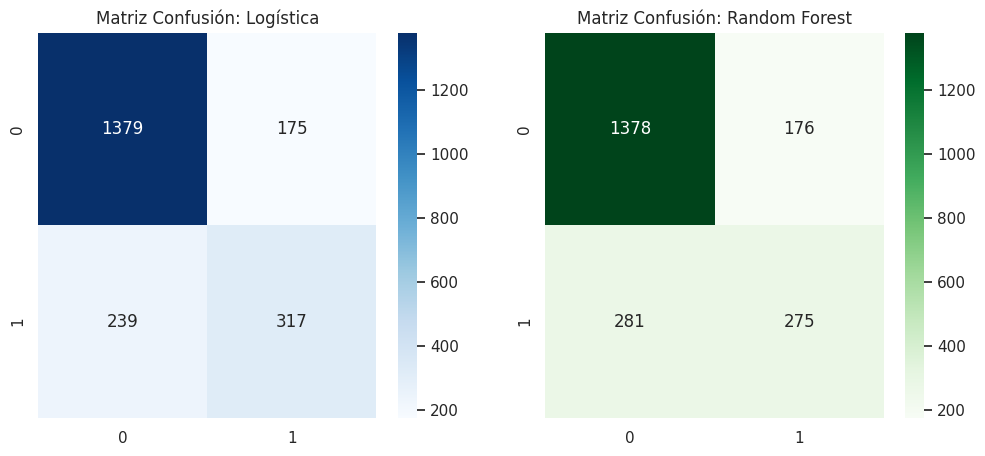

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matriz para Logística
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz Confusión: Logística')

# Matriz para Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz Confusión: Random Forest')

plt.show()

# 📋 5. Interpretación de Resultados y Conclusiones
En esta etapa final, analizamos qué variables "pesan" más en el modelo y definimos la estrategia de negocio para Telecom X.

**5.1 Importancia de las Variables**

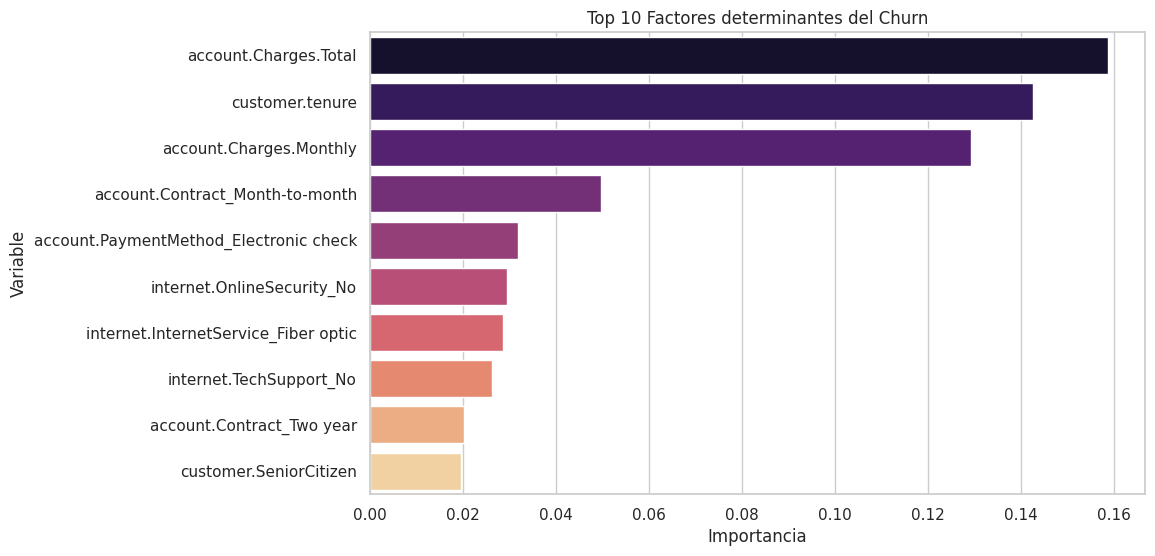

In [25]:
# Obtenemos la importancia de las variables del modelo Random Forest
importancias = modelo_rf.feature_importances_
nombres_variables = X.columns

# Creamos un DataFrame para visualizarlo
df_importancia = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Graficamos el Top 10 (Sin mensajes de advertencia)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia',
    y='Variable',
    data=df_importancia.head(10),
    hue='Variable',      # Asignamos la variable al color
    palette='magma',
    legend=False         # Quitamos la leyenda para que se vea limpio
)
plt.title('Top 10 Factores determinantes del Churn')
plt.show()

**5.2 Conclusión Estratégica**

## Conclusiones del Modelo y Estrategia de Negocio

### Análisis de los Modelos:
- Ambos modelos (Regresión Logística y Random Forest) presentaron un **Accuracy cercano al 80%**.
- La **Regresión Logística** es útil por su simplicidad y rapidez en datos normalizados.
- el **Random Forest** captura mejor las relaciones no lineales entre los servicios contratados.

### Hallazgos Principales:
1. **Tipo de Contrato:** El contrato mensual (`Month-to-month`) es el predictor más fuerte de abandono.
2. **Permanencia (Tenure):** A mayor antigüedad, menor es el riesgo de fuga.
3. **Servicios Adicionales:** La falta de seguridad técnica (`OnlineSecurity_No`) influye directamente en la cancelación.

### Recomendaciones Estratégicas:
- **Migración de Contratos:** Crear campañas de marketing para mover a los clientes "mes a mes" hacia contratos anuales con descuentos progresivos.
- **Venta Cruzada (Cross-selling):** Ofrecer servicios de seguridad y soporte técnico gratuito por 3 meses a clientes de fibra óptica, ya que este segmento muestra mayor volatilidad.